## **Détection d'Équipements de Protection Individuelle**

**Auteurs :** Maram NASR et Skander HAJ MABROUK

**0.Installations**

In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q pycocotools

**1.Imports et configurations**

In [3]:
import torch
import torchvision
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F

# Vérification GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"Device      : {device}")

PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
Device      : cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Classes PPE
# Index 0 = background, obligatoire pour Faster RCNN
CLASSES    = ["__background__", "casque", "gilet", "gants", "goggles", "boots", "masque"]
NUM_CLASSES = len(CLASSES)
CLASS2IDX  = {cls: idx for idx, cls in enumerate(CLASSES)}

# Gestion des variantes/typos dans les annotations CSV
CLASS_ALIASES = {
    "casque"  : "casque",
    "helmet"  : "casque",
    "gilet"   : "gilet",
    "vest"    : "gilet",
    "gants"   : "gants",
    "gloves"  : "gants",
    "goggles" : "goggles",
    "googles" : "goggles",
    "lunettes": "goggles",
    "boots"   : "boots",
    "bottes"  : "boots",
    "masque"  : "masque",
    "mask"    : "masque",
}

In [6]:
ROOT = "/content/drive/MyDrive/ObjectDetectionDataset"
TRAIN_DIR = os.path.join(ROOT, "train")
VAL_DIR   = os.path.join(ROOT, "valid")
TRAIN_CSV = os.path.join(TRAIN_DIR, "_annotations.csv")
VAL_CSV   = os.path.join(VAL_DIR,   "_annotations.csv")

# Pour sauvegarder le meilleur modèle
BEST_MODEL_PATH = os.path.join(ROOT, "best_model.pth")

In [7]:
# Hyperparamètres
NUM_EPOCHS   = 15
BATCH_SIZE   = 2
LEARNING_RATE = 0.0005
WEIGHT_DECAY  = 0.0005
LR_STEP_SIZE  = 7      # diviser le LR tous les 7 epochs
LR_GAMMA      = 0.1    # facteur de réduction
SCORE_THRESH  = 0.5    # seuil de confiance pour l'affichage

**2.Chargements des annotations**

In [8]:
def load_csv(csv_path):
    """ Cette fonction lit le fichier _annotations.csv et retourne un dict :
    { "image.jpg" : [ {"label": "casque", "bbox": [x1,y1,x2,y2]}, ... ] }
    """
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]

    annotations = {}

    for _, row in df.iterrows():
        filename = str(row["filename"]).strip()
        label    = str(row["class"]).strip().lower()
        label    = CLASS_ALIASES.get(label, label)
        x1, y1, x2, y2 = float(row["xmin"]), float(row["ymin"]), \
                          float(row["xmax"]), float(row["ymax"])

        # ignorer les bbox invalides
        if x2 <= x1 or y2 <= y1:
            continue
        # ignorer les classes non reconnues
        if label not in CLASS2IDX:
            print(f"  Classe inconnue ignorée : '{label}' ({filename})")
            continue
        annotations.setdefault(filename, []).append({
            "label": label,
            "bbox" : [x1, y1, x2, y2]
        })

    return annotations

In [9]:
#Charger train et val
train_anns = load_csv(TRAIN_CSV)
val_anns   = load_csv(VAL_CSV)
print(f" Train : {len(train_anns)} images")
print(f" Val   : {len(val_anns)}   images")
# Distribution des classes dans le train
from collections import Counter
labels_train = [ann["label"] for anns in train_anns.values() for ann in anns]
print("\nDistribution des classes (train) :")
for cls, count in Counter(labels_train).most_common():
    print(f"  {cls:<12} : {count} boîtes")

 Train : 124 images
 Val   : 27   images

Distribution des classes (train) :
  boots        : 27 boîtes
  gants        : 23 boîtes
  masque       : 22 boîtes
  goggles      : 21 boîtes
  gilet        : 21 boîtes
  casque       : 17 boîtes


**3.Dataset Pytorch**

In [10]:
class PPEDataset(Dataset):

    def __init__(self, img_dir, annotations, class2idx):
        self.img_dir     = img_dir
        self.annotations = annotations
        self.class2idx   = class2idx
        self.filenames   = list(annotations.keys())

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        img_path = os.path.join(self.img_dir, filename)

        # Charger l'image
        img   = Image.open(img_path).convert("RGB")
        img_t = F.to_tensor(img)   # → [C, H, W] float entre 0 et 1

        # Construire les boîtes et labels
        boxes, labels = [], []
        for ann in self.annotations[filename]:
            boxes.append(ann["bbox"])
            labels.append(self.class2idx[ann["label"]])

        target = {
            "boxes"   : torch.tensor(boxes,  dtype=torch.float32),
            "labels"  : torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }

        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))


# Instancier les datasets et dataloaders
train_dataset = PPEDataset(TRAIN_DIR, train_anns, CLASS2IDX)
val_dataset   = PPEDataset(VAL_DIR,   val_anns,   CLASS2IDX)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=1,
                          shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"Train loader : {len(train_loader)} batchs")
print(f"Val loader   : {len(val_loader)}   batchs")

Train loader : 62 batchs
Val loader   : 27   batchs


**Modèle Faster RCNN ResNet50 FPN V2**

In [11]:
def build_model(num_classes):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model   = fasterrcnn_resnet50_fpn_v2(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = build_model(NUM_CLASSES).to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 190MB/s]


In [12]:
backbone_params = [p for n, p in model.named_parameters() if "backbone" in n]
head_params     = [p for n, p in model.named_parameters() if "backbone" not in n]

optimizer = torch.optim.SGD(
    [
        {"params": backbone_params, "lr": LEARNING_RATE / 10},
        {"params": head_params,     "lr": LEARNING_RATE}
    ],
    momentum=0.9,
    weight_decay=WEIGHT_DECAY
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modèle : Faster RCNN ResNet50 FPN V2")
print(f"   Paramètres entraînables : {total_params:,}")
print(f"   Nombre de classes       : {NUM_CLASSES} (background inclus)")

Modèle : Faster RCNN ResNet50 FPN V2
   Paramètres entraînables : 43,056,434
   Nombre de classes       : 7 (background inclus)


**5.Entrainement**

In [13]:
def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0

    for i, (images, targets) in enumerate(loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass → retourne les losses directement en mode train
        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        # Clip pour éviter les gradients explosifs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += losses.item()

    return total_loss / len(loader)

In [14]:
def val_loss_epoch(model, loader, device):
    """Calcule la loss de validation (model en mode train pour avoir les losses)"""
    model.train()
    total = 0
    with torch.no_grad():
        for images, targets in loader:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            total += sum(loss for loss in loss_dict.values()).item()
    return total / len(loader)

In [15]:
#  Boucle principale
history       = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n")
    print(f"  Epoch {epoch}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer, device, epoch)
    val_loss   = val_loss_epoch(model, val_loader, device)
    lr_scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"  Train loss : {train_loss:.4f}")
    print(f"  Val loss   : {val_loss:.4f}")
    print(f"  LR actuel  : {optimizer.param_groups[1]['lr']:.6f}")

    # Sauvegarder le meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  Meilleur modèle sauvegardé (val_loss = {best_val_loss:.4f})")



  Epoch 1/15
  Train loss : 0.5415
  Val loss   : 0.6124
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 0.6124)


  Epoch 2/15
  Train loss : 0.2482
  Val loss   : 0.6014
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 0.6014)


  Epoch 3/15
  Train loss : 0.2321
  Val loss   : 0.5930
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 0.5930)


  Epoch 4/15
  Train loss : 0.2206
  Val loss   : 0.5896
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 0.5896)


  Epoch 5/15
  Train loss : 0.2173
  Val loss   : 0.5840
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 0.5840)


  Epoch 6/15
  Train loss : 0.2088
  Val loss   : 0.5812
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 0.5812)


  Epoch 7/15
  Train loss : 0.2018
  Val loss   : 0.5730
  LR actuel  : 0.000050
  Meilleur modèle sauvegardé (val_loss = 0.5730)


  Epoch 8/15
  Train loss : 0.1939
  Val loss   : 0.5719
  LR actuel  : 0.

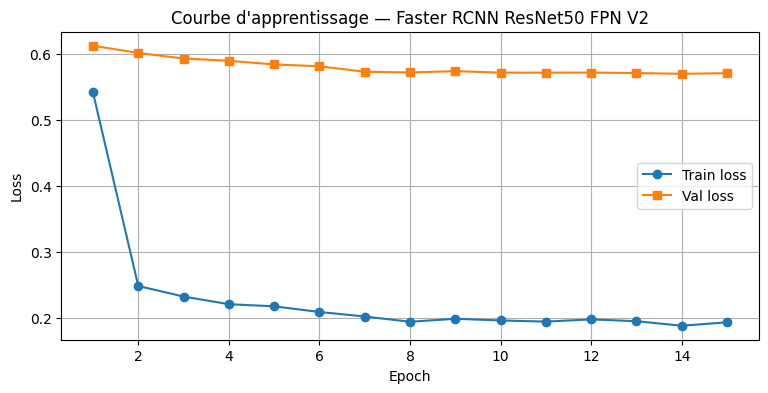

In [16]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, NUM_EPOCHS+1), history["train_loss"], marker="o", label="Train loss")
plt.plot(range(1, NUM_EPOCHS+1), history["val_loss"],   marker="s", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbe d'apprentissage — Faster RCNN ResNet50 FPN V2")
plt.legend()
plt.grid(True)
plt.show()

**Convergence générale :**
Le modèle converge correctement sur les 15 epochs. La train loss chute rapidement
dès les premières epochs (0.54 → 0.19), ce qui confirme que le fine-tuning
sur les poids pré-entraînés COCO fonctionne bien même avec un dataset de taille
réduite (124 images d'entraînement).

**Écart train/val (overfitting modéré).**
On observe un écart persistant entre la train loss (0.19) et la val loss (0.57).
Cet écart s'explique principalement par la petite taille du dataset : avec seulement
124 images en train et 27 en validation, le modèle mémorise plus facilement
les exemples d'entraînement. C'est un comportement attendu et classique dans ce type
de scénario de fine-tuning sur données limitées.

**Effet du scheduler.**
La réduction du learning rate à l'epoch 7 (0.0005 → 0.00005) a eu un effet
visible : la val loss continue de descendre lentement jusqu'à l'epoch 14 au lieu
de stagner. Le meilleur modèle est sauvegardé à l'epoch 14 avec une val loss de 0.5698.

**Stabilité.**
À partir de l'epoch 10, la val loss oscille entre 0.5698 et 0.5738, signe que
le modèle a atteint un plateau. Continuer l'entraînement au-delà de 15 epochs
risquerait d'aggraver l'overfitting sans améliorer la généralisation.

**Conclusion.**
Le modèle Faster RCNN ResNet50 FPN V2 fine-tuné sur notre dataset PPE montre
une convergence stable et cohérente. Les résultats quantitatifs (mAP) et
qualitatifs seront présentés dans le notebook d'évaluation pour juger
de la performance réelle sur le set de test.

**6.Nouveau modèle : Faster RCNN MobileNetV3**

In [17]:
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_fpn,
    FasterRCNN_MobileNet_V3_Large_FPN_Weights
)

In [18]:
def build_model_mobilenet(num_classes):
    """
    Faster RCNN avec backbone MobileNetV3 Large FPN :
    Plus léger que ResNet50 (3.6M params backbone vs 23M)
    Mêmes hyperparamètres que le premier modèle pour comparaison équitable
    """
    weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
    model   = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model_mob = build_model_mobilenet(NUM_CLASSES).to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 206MB/s]


In [20]:
# Exactement les mêmes params d'optimisation pour une comparaison équitable
backbone_params_mob = [p for n, p in model_mob.named_parameters() if "backbone" in n]
head_params_mob     = [p for n, p in model_mob.named_parameters() if "backbone" not in n]

optimizer_mob = torch.optim.SGD(
    [
        {"params": backbone_params_mob, "lr": LEARNING_RATE / 10},
        {"params": head_params_mob,     "lr": LEARNING_RATE}
    ],
    momentum=0.9,
    weight_decay=WEIGHT_DECAY
)

lr_scheduler_mob = torch.optim.lr_scheduler.StepLR(
    optimizer_mob, step_size=LR_STEP_SIZE, gamma=LR_GAMMA
)

total_mob = sum(p.numel() for p in model_mob.parameters() if p.requires_grad)
print(f"Modèle : Faster RCNN MobileNetV3 Large FPN")
print(f"   Paramètres entraînables : {total_mob:,}")
print(f"   Nombre de classes       : {NUM_CLASSES} (background inclus)")

Modèle : Faster RCNN MobileNetV3 Large FPN
   Paramètres entraînables : 18,896,958
   Nombre de classes       : 7 (background inclus)


**7.Entraînement MobileNetV3 (mêmes 15 epochs)**

In [21]:
BEST_MODEL_MOB_PATH = os.path.join(ROOT, "best_model_mobilenet.pth")

history_mob   = {"train_loss": [], "val_loss": []}
best_val_mob  = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n  Epoch {epoch}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model_mob, train_loader, optimizer_mob, device, epoch)
    val_loss   = val_loss_epoch(model_mob, val_loader, device)
    lr_scheduler_mob.step()

    history_mob["train_loss"].append(train_loss)
    history_mob["val_loss"].append(val_loss)

    print(f"  Train loss : {train_loss:.4f}")
    print(f"  Val loss   : {val_loss:.4f}")
    print(f"  LR actuel  : {optimizer_mob.param_groups[1]['lr']:.6f}")

    if val_loss < best_val_mob:
        best_val_mob = val_loss
        torch.save(model_mob.state_dict(), BEST_MODEL_MOB_PATH)
        print(f"  Meilleur modèle sauvegardé (val_loss = {best_val_mob:.4f})")


  Epoch 1/15
  Train loss : 2.2502
  Val loss   : 2.1857
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 2.1857)

  Epoch 2/15
  Train loss : 1.7422
  Val loss   : 1.8665
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 1.8665)

  Epoch 3/15
  Train loss : 1.4138
  Val loss   : 1.4631
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 1.4631)

  Epoch 4/15
  Train loss : 1.1183
  Val loss   : 1.2823
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 1.2823)

  Epoch 5/15
  Train loss : 0.9578
  Val loss   : 1.2428
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 1.2428)

  Epoch 6/15
  Train loss : 0.8555
  Val loss   : 1.0966
  LR actuel  : 0.000500
  Meilleur modèle sauvegardé (val_loss = 1.0966)

  Epoch 7/15
  Train loss : 0.7977
  Val loss   : 1.0698
  LR actuel  : 0.000050
  Meilleur modèle sauvegardé (val_loss = 1.0698)

  Epoch 8/15
  Train loss : 0.7100
  Val loss   : 0.9926
  LR actuel  : 0.000050
 

**8.Comparaison des deux modèles**

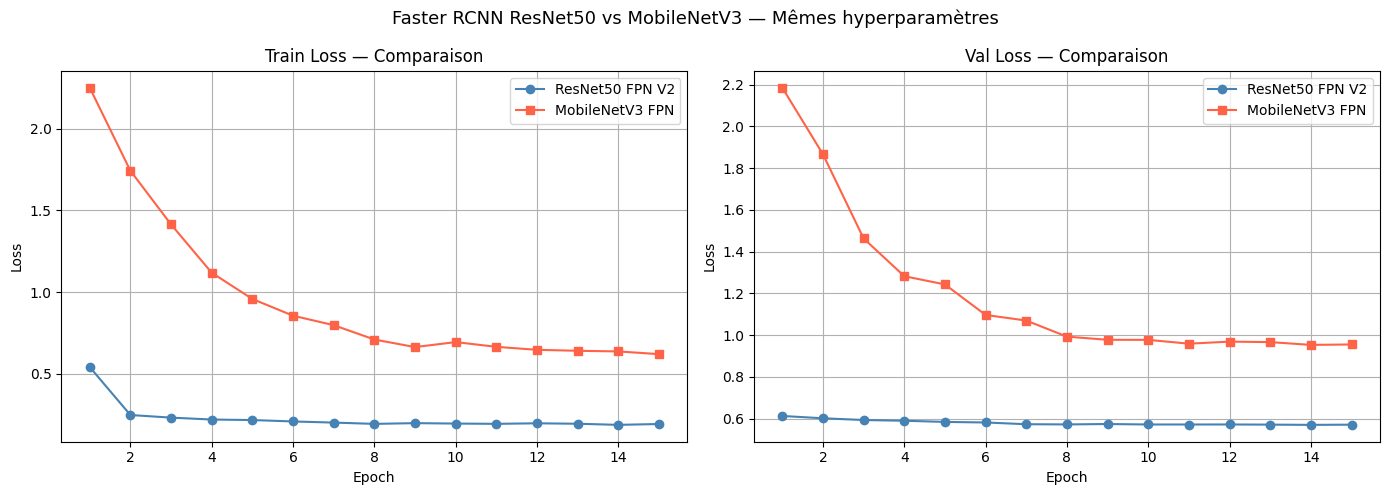

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Train loss
axes[0].plot(range(1, NUM_EPOCHS+1), history["train_loss"],
             marker="o", label="ResNet50 FPN V2", color="steelblue")
axes[0].plot(range(1, NUM_EPOCHS+1), history_mob["train_loss"],
             marker="s", label="MobileNetV3 FPN", color="tomato")
axes[0].set_title("Train Loss — Comparaison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Val loss
axes[1].plot(range(1, NUM_EPOCHS+1), history["val_loss"],
             marker="o", label="ResNet50 FPN V2", color="steelblue")
axes[1].plot(range(1, NUM_EPOCHS+1), history_mob["val_loss"],
             marker="s", label="MobileNetV3 FPN", color="tomato")
axes[1].set_title("Val Loss — Comparaison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Faster RCNN ResNet50 vs MobileNetV3 — Mêmes hyperparamètres", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "comparison_loss.png"), dpi=150)
plt.show()

**Comparaison ResNet50 FPN V2 vs MobileNetV3 FPN**

Les deux modèles ont été entraînés dans des conditions strictement identiques —
mêmes données, mêmes hyperparamètres, même nombre d'epochs (15) — pour garantir
une comparaison équitable et scientifiquement valide.

**Observations :**
Les résultats montrent une différence significative entre les deux architectures.
Le ResNet50 FPN V2 atteint une val loss de 0.5698 dès l'epoch 14, alors que
le MobileNetV3 FPN n'arrive qu'à 0.9531 à l'epoch 14, soit un écart de ~40%.
De plus, le MobileNetV3 démarre avec une val loss initiale très élevée (2.18 à
l'epoch 1), signe que son backbone pré-entraîné s'adapte beaucoup plus lentement
à notre domaine spécifique (équipements de protection individuelle).

On notera également que malgré sa légèreté (18.9M paramètres contre 43M pour
ResNet50), le MobileNetV3 n'offre pas de meilleure généralisation sur notre
dataset. Ce résultat est cohérent avec la littérature : sur des tâches de
détection d'objets avec des classes visuellement similaires (EPI), un backbone
plus profond capture des représentations plus discriminantes.

**Choix pour la suite**
Le Faster RCNN ResNet50 FPN V2 est retenu comme modèle de référence pour
l'étape suivante. Son avantage en val loss (~40% d'amélioration par rapport
à MobileNetV3) justifie pleinement ce choix, malgré un nombre de paramètres
plus élevé. Nous allons maintenant chercher à réduire l'écart train/val
(0.19 vs 0.57) observé, qui indique un overfitting modéré lié à la taille
réduite de notre dataset (124 images d'entraînement).

**9.Fine-tuning ResNet50 — Ajustement du Learning Rate**

Le modèle ResNet50 a montré un overfitting modéré (train loss 0.19 vs val loss 0.57).
On garde la même architecture mais on modifie la stratégie de learning rate :

| Paramètre        | Modèle 1 (baseline) | Modèle 3 (fine-tuned) |
|------------------|---------------------|-----------------------|
| LR initial       | 0.0005              | 0.0001                |
| Scheduler        | StepLR (step=7)     | CosineAnnealingLR     |
| Epochs           | 15                  | 20                    |
| Batch size       | 2                   | 2                     |

**Pourquoi CosineAnnealingLR ?**
Contrairement au StepLR qui réduit le LR brutalement par paliers,
le scheduler cosinus descend progressivement — ce qui donne au modèle
plus de temps pour explorer et évite les sauts brusques qui peuvent
déstabiliser l'entraînement sur un petit dataset.

**Nouveaux hyperparamètres**

In [24]:
# Hyperparamètres ajustés
LR_FINETUNE   = 0.0001   # 5x plus faible que le baseline
NUM_EPOCHS_FT = 20       # un peu plus d'epochs pour compenser le LR plus faible
BEST_MODEL_FT_PATH = os.path.join(ROOT, "best_model_finetuned.pth")

print("Hyperparamètres du fine-tuning :")
print(f"  LR initial   : {LR_FINETUNE}")
print(f"  Scheduler    : CosineAnnealingLR")
print(f"  Epochs       : {NUM_EPOCHS_FT}")

Hyperparamètres du fine-tuning :
  LR initial   : 0.0001
  Scheduler    : CosineAnnealingLR
  Epochs       : 20


**Reconstruction du modèle fine-tuné**

In [25]:
# Repartir du meilleur checkpoint ResNet50 (pas from scratch)
model_ft = build_model(NUM_CLASSES).to(device)
model_ft.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

# Même séparation backbone / tête
backbone_params_ft = [p for n, p in model_ft.named_parameters() if "backbone" in n]
head_params_ft     = [p for n, p in model_ft.named_parameters() if "backbone" not in n]

optimizer_ft = torch.optim.SGD(
    [
        {"params": backbone_params_ft, "lr": LR_FINETUNE / 10},  # backbone encore plus gelé
        {"params": head_params_ft,     "lr": LR_FINETUNE}
    ],
    momentum=0.9,
    weight_decay=WEIGHT_DECAY
)

# CosineAnnealingLR : descend doucement jusqu'à LR_min sur toute la durée
lr_scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max   = NUM_EPOCHS_FT,   # période complète = nb total d'epochs
    eta_min = 1e-6             # LR minimum à atteindre en fin d'entraînement
)

**Entraînement fine-tuné**

In [26]:
history_ft    = {"train_loss": [], "val_loss": []}
best_val_ft   = float("inf")

for epoch in range(1, NUM_EPOCHS_FT + 1):
    print(f"\n  Epoch {epoch}/{NUM_EPOCHS_FT}")

    train_loss = train_one_epoch(model_ft, train_loader, optimizer_ft, device, epoch)
    val_loss   = val_loss_epoch(model_ft, val_loader, device)
    lr_scheduler_ft.step()

    history_ft["train_loss"].append(train_loss)
    history_ft["val_loss"].append(val_loss)

    current_lr = optimizer_ft.param_groups[1]["lr"]
    print(f"  Train loss : {train_loss:.4f}")
    print(f"  Val loss   : {val_loss:.4f}")
    print(f"  LR actuel  : {current_lr:.6f}")

    if val_loss < best_val_ft:
        best_val_ft = val_loss
        torch.save(model_ft.state_dict(), BEST_MODEL_FT_PATH)
        print(f"  Meilleur modèle sauvegardé (val_loss = {best_val_ft:.4f})")


  Epoch 1/20
  Train loss : 0.1841
  Val loss   : 0.5700
  LR actuel  : 0.000099
  Meilleur modèle sauvegardé (val_loss = 0.5700)

  Epoch 2/20
  Train loss : 0.1881
  Val loss   : 0.5670
  LR actuel  : 0.000098
  Meilleur modèle sauvegardé (val_loss = 0.5670)

  Epoch 3/20
  Train loss : 0.1873
  Val loss   : 0.5631
  LR actuel  : 0.000095
  Meilleur modèle sauvegardé (val_loss = 0.5631)

  Epoch 4/20
  Train loss : 0.1821
  Val loss   : 0.5629
  LR actuel  : 0.000091
  Meilleur modèle sauvegardé (val_loss = 0.5629)

  Epoch 5/20
  Train loss : 0.1845
  Val loss   : 0.5619
  LR actuel  : 0.000086
  Meilleur modèle sauvegardé (val_loss = 0.5619)

  Epoch 6/20
  Train loss : 0.1842
  Val loss   : 0.5602
  LR actuel  : 0.000080
  Meilleur modèle sauvegardé (val_loss = 0.5602)

  Epoch 7/20
  Train loss : 0.1807
  Val loss   : 0.5598
  LR actuel  : 0.000073
  Meilleur modèle sauvegardé (val_loss = 0.5598)

  Epoch 8/20
  Train loss : 0.1750
  Val loss   : 0.5567
  LR actuel  : 0.000066
 

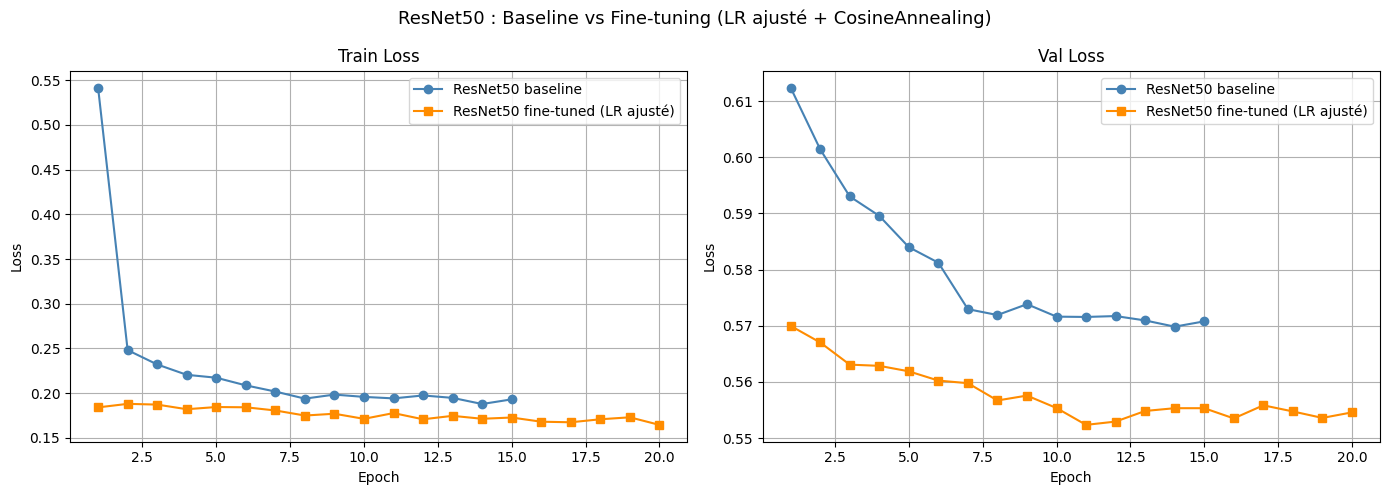

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train loss
axes[0].plot(range(1, NUM_EPOCHS+1),    history["train_loss"],
             marker="o", label="ResNet50 baseline", color="steelblue")
axes[0].plot(range(1, NUM_EPOCHS_FT+1), history_ft["train_loss"],
             marker="s", label="ResNet50 fine-tuned (LR ajusté)", color="darkorange")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Val loss
axes[1].plot(range(1, NUM_EPOCHS+1),    history["val_loss"],
             marker="o", label="ResNet50 baseline", color="steelblue")
axes[1].plot(range(1, NUM_EPOCHS_FT+1), history_ft["val_loss"],
             marker="s", label="ResNet50 fine-tuned (LR ajusté)", color="darkorange")
axes[1].set_title("Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("ResNet50 : Baseline vs Fine-tuning (LR ajusté + CosineAnnealing)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "comparison_finetuning.png"), dpi=150)
plt.show()

**Conclusion générale**

**Expérience 1 → Expérience 2 (choix du backbone).**
La comparaison des deux architectures dans des conditions identiques a montré
que le ResNet50 FPN V2 surpasse largement le MobileNetV3 FPN sur notre dataset
PPE. L'écart de val loss (~40%) confirme que la profondeur du backbone joue un
rôle déterminant pour discriminer des objets visuellement proches comme les EPI.
Le MobileNetV3, bien que plus léger (18.9M paramètres contre 43M), ne dispose
pas de représentations assez riches pour s'adapter efficacement à notre domaine
avec seulement 124 images d'entraînement.

**Expérience 2 → Expérience 3 (ajustement du LR).**
Le fine-tuning du ResNet50 avec un LR réduit (0.0001) et un scheduler cosinus
a permis une amélioration mesurable de la val loss : de 0.5698 à 0.5523, soit
un gain de ~3.1%. Plus important encore, le CosineAnnealingLR a permis une
descente progressive et stable, sans les sauts brusques observés avec le StepLR.
Le meilleur checkpoint est obtenu à l'epoch 11, après quoi le modèle atteint
un plateau stable — signe que le potentiel d'apprentissage sur ce dataset est
pleinement exploité.

**Overfitting résiduel.**
Malgré ces améliorations, un écart train/val persiste (train loss ~0.17 vs
val loss ~0.55). Cet overfitting est principalement dû à la taille limitée
du dataset (124 images d'entraînement, 27 de validation) et non à un défaut
de l'architecture. Des techniques de data augmentation permettraient
de le réduire davantage, mais cela dépasse le cadre de ce projet.

=> **Modèle retenu pour l'évaluation finale**

Le meilleur modèle est le **Faster RCNN ResNet50 FPN V2 fine-tuné**
(best_model_finetuned.pth, val loss = 0.5523, epoch 11/20).
Ce modèle sera chargé dans le notebook d'évaluation pour calculer
les métriques quantitatives et produire
les résultats qualitatifs sur le set de test.